In [1]:
import os

os.environ['XILINX_VIVADO'] = '/tools/Xilinx2/Vivado/2020.1'
os.environ['PATH'] = os.environ['XILINX_VIVADO'] + '/bin:' + os.environ['PATH']

In [2]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, Flatten, Dense

def create_simple_cnn(input_shape):
    model = Sequential()
    model.add(Conv2D(2, (3, 3), activation='relu', input_shape=input_shape))
    model.add(Flatten())
    model.add(Dense(2, activation='softmax'))  # Output layer for 2 classes (RFI, FRB)
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# Define the input shape
input_shape = (32, 32, 1)

model = create_simple_cnn(input_shape)

model.summary()

2025-09-18 00:58:50.197017: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2025-09-18 00:59:20.551366: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2025-09-18 00:59:20.611518: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-09-18 01:00:31.975332: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 30, 30, 2)         20        
                                                                 
 flatten (Flatten)           (None, 1800)              0         
                                                                 
 dense (Dense)               (None, 2)                 3602      
                                                                 
Total params: 3,622
Trainable params: 3,622
Non-trainable params: 0
_________________________________________________________________


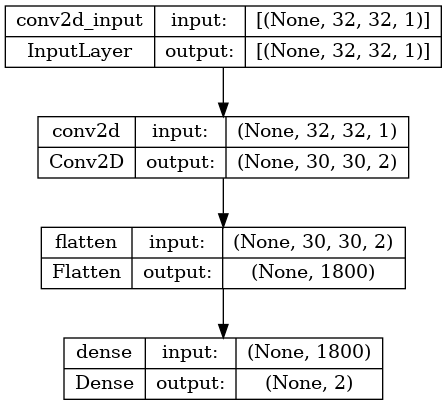

In [3]:
from tensorflow.keras.utils import plot_model
plot_model(model, show_shapes=True, show_layer_names=True)

In [4]:
import hls4ml
from hls4ml.utils.config import config_from_keras_model
from hls4ml.converters import convert_from_keras_model

hls_config = config_from_keras_model(
    model, granularity='name', backend='Vivado', default_precision='ap_fixed<4, 2>'
)

hls_config['LayerName']['dense']['Strategy'] = 'Resource'
hls_config['LayerName']['dense']['ReuseFactor'] = 4

hls_model = convert_from_keras_model(
    model,
    hls_config=hls_config,
    output_dir="simple_fetch_model",
    backend='Vivado',
    part='xcvu9p-flga2104-2L-e',
    io_type='io_stream',
)

hls_model.compile()

Interpreting Sequential
Topology:
Layer name: conv2d_input, layer type: InputLayer, input shapes: [[None, 32, 32, 1]], output shape: [None, 32, 32, 1]
Layer name: conv2d, layer type: Conv2D, input shapes: [[None, 32, 32, 1]], output shape: [None, 30, 30, 2]
Layer name: flatten, layer type: Reshape, input shapes: [[None, 30, 30, 2]], output shape: [None, 1800]
Layer name: dense, layer type: Dense, input shapes: [[None, 1800]], output shape: [None, 2]
Interpreting Sequential
Topology:
Layer name: conv2d_input, layer type: InputLayer, input shapes: [[None, 32, 32, 1]], output shape: [None, 32, 32, 1]
Layer name: conv2d, layer type: Conv2D, input shapes: [[None, 32, 32, 1]], output shape: [None, 30, 30, 2]
Layer name: flatten, layer type: Reshape, input shapes: [[None, 30, 30, 2]], output shape: [None, 1800]
Layer name: dense, layer type: Dense, input shapes: [[None, 1800]], output shape: [None, 2]
Creating HLS model
Writing HLS project
Done


In [5]:
hls_model.build(csim=False, synth=False, vsynth=False)


****** Vivado(TM) HLS - High-Level Synthesis from C, C++ and SystemC v2020.1 (64-bit)
  **** SW Build 2902540 on Wed May 27 19:54:35 MDT 2020
  **** IP Build 2902112 on Wed May 27 22:43:36 MDT 2020
    ** Copyright 1986-2020 Xilinx, Inc. All Rights Reserved.

source /tools/Xilinx2/Vivado/2020.1/scripts/vivado_hls/hls.tcl -notrace
INFO: [HLS 200-10] Running '/tools/Xilinx2/Vivado/2020.1/bin/unwrapped/lnx64.o/vivado_hls'
INFO: [HLS 200-10] For user 'coder' on host 'coder-apk66-hls4ml-tutorial' (Linux_x86_64 version 5.15.0-131-generic) on Thu Sep 18 01:06:07 UTC 2025
INFO: [HLS 200-10] On os Ubuntu 20.04.6 LTS
INFO: [HLS 200-10] In directory '/home/coder/hls4ml/simple_fetch_model'
Sourcing Tcl script 'build_prj.tcl'
INFO: [HLS 200-10] Opening project '/home/coder/hls4ml/simple_fetch_model/myproject_prj'.
INFO: [HLS 200-10] Adding design file 'firmware/myproject.cpp' to the project
INFO: [HLS 200-10] Adding test bench file 'myproject_test.cpp' to the project
INFO: [HLS 200-10] Adding test

{}